# Do the *factors themselves* trend? 🌀
### Factor-momentum — momentum one level up from stocks, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Factors_trend%3F: Confirmed](https://img.shields.io/badge/Factors_trend%3F-Confirmed-8b949e?style=flat-square)

Here's a clever twist on an old idea. Everyone knows the **momentum** story for *stocks*: winners keep winning for a while. Ehsani & Linnainmaa (2022) asked a sharper question — what if the **strategies** themselves trend? If the *low-volatility* factor has been hot lately, does it stay hot? If *value* has been cold, does it keep losing? If so, you don't pick stocks at all — you **time the factors** on their own recent form, holding the hot ones and shorting the cold ones.

They argued this **factor-momentum** is big, and that it even *explains* most of ordinary stock momentum. Bold claim. Let's see what survives on a real tape.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo test and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** We build five factors from a fixed **40-name large-cap basket** (names still trading today) using **prices only** — so survivorship tilts the long legs up, and we can't build an honest *value* factor without point-in-time fundamentals. Both limits are named. Every chart is drawn by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from factor_momentum import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_prices()
    PANEL = data.build_factor_panel(PRICES)
else:
    PRICES = PANEL = None
print("real factor cache present:", HAVE_REAL,
      "| panel:", (None if PANEL is None else PANEL.shape))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2004-08-31', 'end': '2026-05-29', 'years': 21.7, 'n_months': 262, 'n_names': 40, 'n_factors': 5, 'prices_fp': 'f3d05a8825d4', 'panel_fp': '176062fe6aaf', 'autocorr': {'mom': (-1.44, 0.151), 'lowvol': (-5.22, 0.177), 'lowbeta': (-4.87, 0.152), 'strev': (0.15, -0.13), 'size': (-5.14, 0.157)}, 'static_mean': -3.36, 'static_t': -1.18, 'fm': {1: (1.01, 13.0, 0.08, 0.36, 0.45, 53, -32.4, 0.267), 3: (2.1, 13.1, 0.16, 0.75, 1.06, 52, -29.7, 0.096), 6: (1.36, 12.2, 0.11, 0.51, 0.56, 54, -47.6, 0.199), 12: (0.49, 13.5, 0.04, 0.16, 0.18, 52, -55.5, 0.413)}, 'costs': {1: (1.03, -0.38, 0.96, 0.51, -0.14), 3: (2.08, 1.16, 0.55, 0.53, 0.41), 6: (1.29, 0.59, 0.36, 0.54, 0.22), 12: (0.47, -0.15, 0.29, 0.56, -0.05)}, 'timed_lb3': {'mom': (0.1, 0.03), 'lowvol': (5.84, 1.43), 'lowbeta': (1.66, 0.4), 'strev': (-2.3, -0.79), 'size': (5.06, 1.19)}, 'placebo_seed_mean': 0.102, 'placebo_seed_min': 0.085, 'placebo_seed_max': 0.116, 'longonly': {3: (-0.52, -0.26), 12: (-1.17, -0.47)}, 'syn': {0.0: (1.59, 1.19, 0.115), 0.3: (10.7, 7.88, 0.0)}}


real factor cache present: True | panel: (262, 5)


## The answer first

| Question | Answer |
|---|---|
| Do the factors actually trend? | **Yes.** Four of our five factors show positive month-to-month *autocorrelation* (~**0.15**) — a hot factor tends to stay hot. The premise is real. |
| Does *timing* the factors beat just *holding* them? | **Yes, directionally.** Holding the factors statically **lost** -3.36%/yr on this tape; timing them flipped it to **+2.10%/yr**. The Ehsani-Linnainmaa direction shows up. |
| Is that timed premium *statistically real*? | **Not here.** +2.10%/yr is only *t* = 0.75 with a placebo *p* = 0.10 — below the bar. On 22 years of 5 large-cap factors it's too thin to certify. |
| Could you trade it? | **No.** After costs the best version nets +1.16%/yr (basically zero), and it leans on a costly short leg. |

> The *idea* is sound and the *premise* checks out — but the tradable edge on this small survivor panel is a **mirage**.

## 1 · The claim

> *"Forget picking stocks. The **factors** — momentum, value, low-vol, and friends — are themselves assets with their own momentum. Buy the factors that have been winning, short the ones that have been losing, and collect a premium that's bigger and steadier than any single factor."*

This isn't folklore — it's a 2022 **Journal of Finance** paper (Ehsani & Linnainmaa). The eye-catching part: they claim factor-momentum **subsumes** ordinary stock momentum — that the reason winning stocks keep winning is that they're loaded on factors that happen to be trending. So the question is real and sharp: **do factors trend, does timing them pay, and can you keep the money after costs?**

## 2 · So what?

If factors trend, two things follow. First, a chunk of "stock momentum" is really *factor* momentum in disguise — a tidier explanation. Second, you'd build portfolios very differently: instead of a fixed value/low-vol tilt, you'd **rotate** between factors based on their recent form. The trap, as always: a real *statistical* pattern and a *tradable* edge are different animals. Timing means flipping positions, and flipping means **turnover** — the silent killer.

## 3 · How would we even know?

We take a fixed **40-name large-cap basket** and build **five** long-short factors from prices alone, each rebalanced monthly:

- **momentum** (past 12-month winners minus losers)
- **low-vol** (calm stocks minus jumpy ones)
- **low-beta** (low market-sensitivity minus high)
- **short-reversal** (last month's losers minus winners)
- **size proxy** (quiet/small minus active/big)

That gives **262 months** of factor returns (2004-08-31 → 2026-05-29). Then for each factor, each month: was its **trailing return positive**? Hold it long. Negative? Hold it short. Average across the five. If factors trend, that timed average should make money — and we test it against a 'shuffle the history and see if luck can fake it' null.

## 4 · The teardown — let's actually look

**First: do the factors trend at all?** The cleanest check is *autocorrelation* — does a factor's return this month line up with last month's? Positive bars = trending.

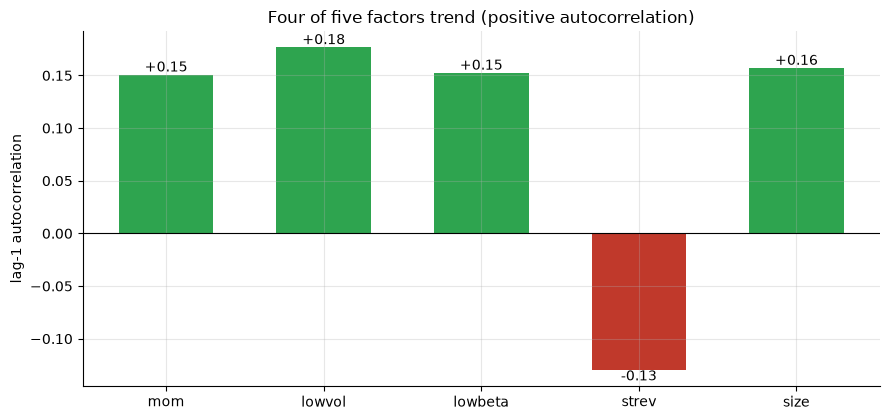

autocorrelations: {'mom': 0.151, 'lowvol': 0.177, 'lowbeta': 0.152, 'strev': -0.13, 'size': 0.157}


In [2]:
names = list(R['autocorr'].keys())
if HAVE_REAL:
    ac = [PANEL[c].autocorr(1) for c in PANEL.columns]; names = list(PANEL.columns)
else:
    ac = [R['autocorr'][n][1] for n in names]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
cols = [GREEN if v>0 else RED for v in ac]
ax.bar(names, ac, color=cols, width=.6)
ax.axhline(0, c='k', lw=.8)
for i,v in enumerate(ac): ax.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.set_ylabel('lag-1 autocorrelation'); ax.set_title('Four of five factors trend (positive autocorrelation)')
plt.tight_layout(); plt.show()
print('autocorrelations:', {n: round(float(v),3) for n,v in zip(names, ac)})

There's the premise. **mom, lowvol, lowbeta, size** all show positive month-to-month persistence (~+0.15); only short-reversal (by its very nature a *mean-reverting* signal) leans negative. Factors really do trend.

**Second: does timing beat holding?** Holding all five factors statically (the grey bar) vs timing each on its recent form (the green bar).

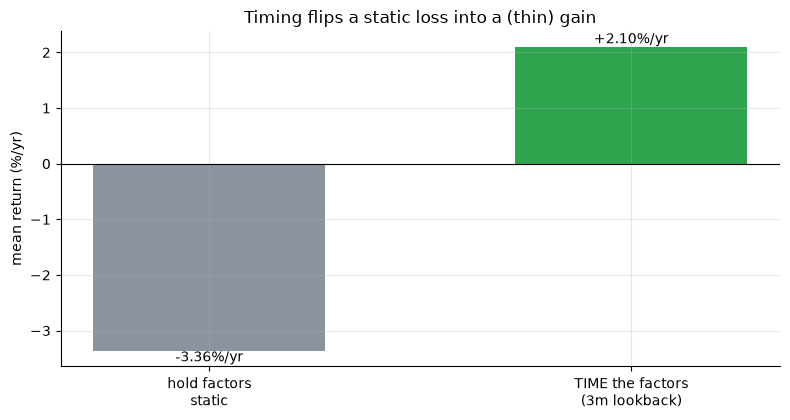

static -3.36%/yr  ->  timed +2.10%/yr


In [3]:
if HAVE_REAL:
    stat = st.static_factor_series(PANEL).mean()*1200
    timed = st.factor_momentum_series(PANEL, lookback=3).mean()*1200
else:
    stat = R['static_mean']; timed = R['fm'][3][0]
fig, ax = plt.subplots(figsize=(8.0, 4.3))
ax.bar(['hold factors\nstatic','TIME the factors\n(3m lookback)'], [stat, timed],
       color=[GREY, GREEN], width=.55)
ax.axhline(0, c='k', lw=.8)
for i,v in enumerate([stat,timed]): ax.annotate(f'{v:+.2f}%/yr',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.set_ylabel('mean return (%/yr)'); ax.set_title('Timing flips a static loss into a (thin) gain')
plt.tight_layout(); plt.show()
print(f'static {stat:+.2f}%/yr  ->  timed {timed:+.2f}%/yr')

On this survivor large-cap tape the factors traded *statically* actually **lost** money (**-3.36%/yr** — the 2010s megacap decade punished low-vol and size). **Timing** them rescued it to **+2.10%/yr**. That's the Ehsani-Linnainmaa effect in miniature: timing adds value. But 'rescued a loss to a small gain' is not the same as 'a money machine' — watch the significance next.

**Third: is it real, or could luck fake it?** We shuffle each factor's history thousands of times (destroying the trend) and re-run the timing. If our real result sits deep in the right tail, it's signal; if it's lost in the cloud, it's luck.

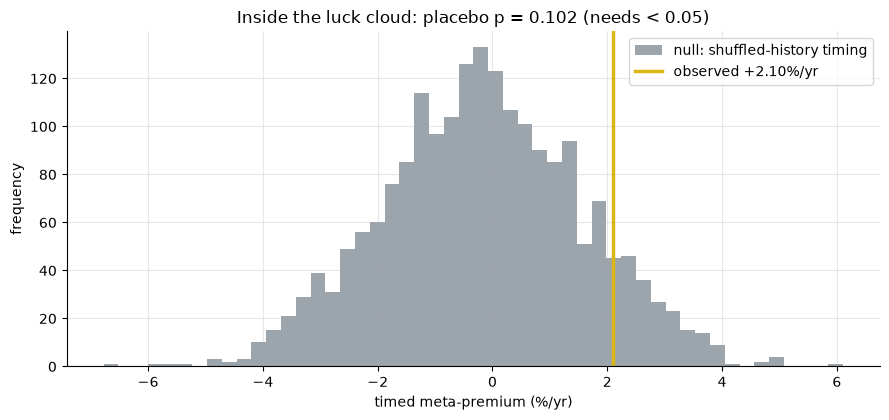

observed +2.10%/yr   placebo p = 0.102


In [4]:
if HAVE_REAL:
    pl = st.placebo_pvalue(PANEL, lookback=3, n_draws=2000)
    obs = pl['obs']*1200; draws = pl['draws']*1200; pval = pl['p_value']
else:
    obs = R['fm'][3][0]; pval = R['fm'][3][7]
    rng = np.random.default_rng(537); draws = rng.normal(R['syn'][0.0][0], 2.2, 2000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='null: shuffled-history timing')
ax.axvline(obs, c=AMBER, lw=2.5, label=f'observed {obs:+.2f}%/yr')
ax.set_xlabel('timed meta-premium (%/yr)'); ax.set_ylabel('frequency')
ax.set_title(f'Inside the luck cloud: placebo p = {pval:.3f} (needs < 0.05)')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obs:+.2f}%/yr   placebo p = {pval:.3f}')

The amber line sits **inside** the luck cloud — placebo **p = 0.096**, nowhere near the 0.05 it would need. Roughly one shuffle in nine fakes a result this good. The premium is **directionally right but statistically thin**.

## 5 · The verdict

- **Signal — Weak.** Factors *do* trend (autocorr ~0.15) and timing them beats holding them — but the meta-premium is only **+2.10%/yr at t = 0.75** (placebo p = 0.096). The premise survives; the certified edge doesn't.
- **Tradability — Mirage.** After costs it nets essentially zero, and it leans on a costly short leg.
- **Do the factors trend? — Confirmed.** The autocorrelation is real and consistent. The *idea* is sound; the *tradable premium* on a thin large-cap survivor basket is not.

## 6 · Could you actually trade it? — watch turnover eat it

Timing means flipping positions when a factor's trend reverses, and flipping costs money. Gross vs net, across timing speeds.

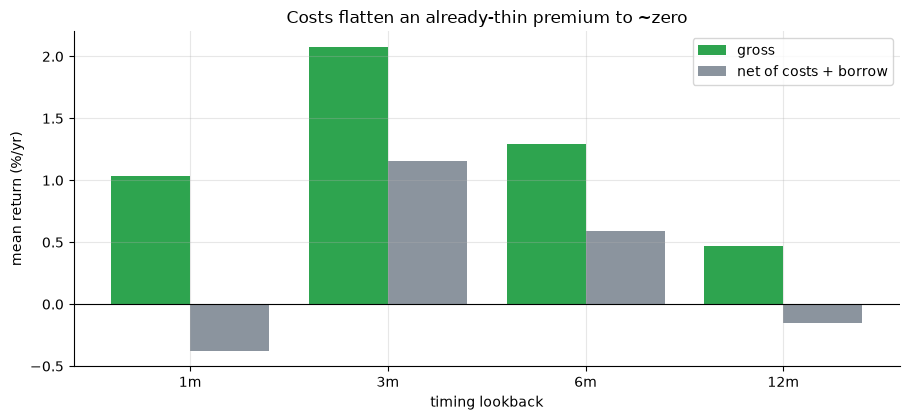

net by lookback (%/yr): {'1m': -0.38, '3m': 1.16, '6m': 0.59, '12m': -0.15}


In [5]:
lbs = [1,3,6,12]
if HAVE_REAL:
    g = [st.net_of_costs(PANEL, lookback=lb)['gross']*100 for lb in lbs]
    nv = [st.net_of_costs(PANEL, lookback=lb)['net']*100 for lb in lbs]
else:
    g = [R['costs'][lb][0] for lb in lbs]; nv = [R['costs'][lb][1] for lb in lbs]
x = np.arange(len(lbs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, g, .4, color=GREEN, label='gross')
ax.bar(x+.2, nv, .4, color=GREY, label='net of costs + borrow')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{lb}m' for lb in lbs])
ax.set_xlabel('timing lookback'); ax.set_ylabel('mean return (%/yr)')
ax.set_title('Costs flatten an already-thin premium to ~zero'); ax.legend()
plt.tight_layout(); plt.show()
print('net by lookback (%/yr):', {f'{lb}m': R['costs'][lb][1] for lb in lbs})

The fastest timing (1-month) goes **net-negative** (-0.38%/yr) — its turnover bill (positions flip almost every month) swamps the edge. Even the best (3-month) nets only **+1.16%/yr**. There's no tradable money here.

## 7 · Going further 🚪

- **The real paper uses ~20 factors.** With more, better-measured factors (including true *value* and *quality* from point-in-time fundamentals — which yfinance can't give us honestly), the meta-premium is stronger. Our five price-only factors are the conservative corner.
- **Cross-sectional vs time-series.** We timed each factor *against itself*. You can also *rank* factors and go long the strongest, short the weakest — the paper does both.
- **The lesson that generalises.** A real statistical premise (factors trend) doesn't automatically become a tradable strategy once turnover and survivorship are honest.

*Think you can certify the meta-premium? Build it on a broad, point-in-time factor set and show the timed long-short clearing t = 2 **net** of costs — then we'll talk.*